In [8]:
from fredapi import Fred
from fred_api_key import API_KEY
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
VIX_THRESH = 10
USD_MA_LEN = 100

fred = Fred(api_key=API_KEY)

# sp500 df
spy = pd.DataFrame(fred.get_series('SP500'), columns=['Close'])
spy['Cumulative'] = (1 + spy['Close'].pct_change(fill_method=None)).cumprod() -1

# vix df
vix = pd.DataFrame(fred.get_series('VIXCLS'), columns=['VIX'])
vix['Cutoff'] = VIX_THRESH

# usd df
usd = pd.DataFrame(fred.get_series('DTWEXBGS'), columns=['USD'])
usd['MA'] = usd['USD'].rolling(USD_MA_LEN, min_periods=1).mean()
usd['Weaker'] = usd['USD'] < usd['MA']

Text(0.5, 1.0, 'SPY Cumulative Returns')

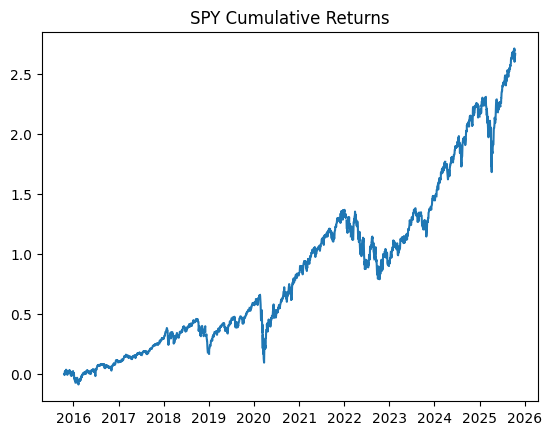

In [10]:
spy.dropna()
plt.plot(spy['Cumulative'])
plt.title('SPY Cumulative Returns')

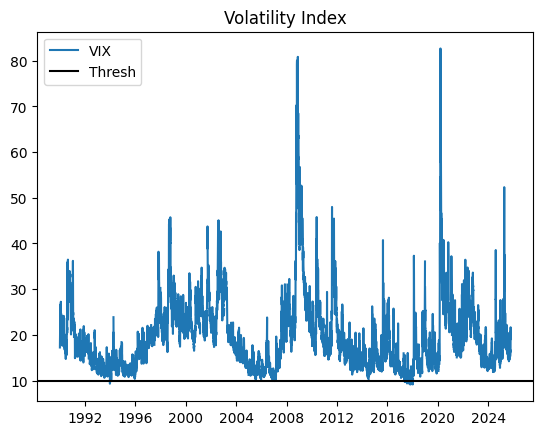

In [11]:
vix.dropna()
plt.plot(vix['VIX'])
plt.axhline(VIX_THRESH, color='black')
plt.title('Volatility Index')
plt.legend(['VIX', 'Thresh'])

Text(0.5, 1.0, 'USD Exchange Rate with Moving Average')

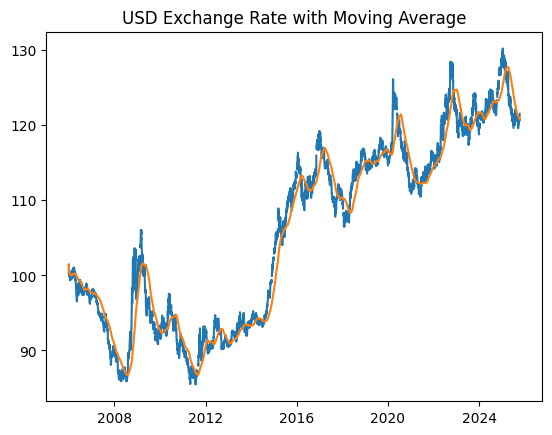

In [12]:
usd.dropna()
plt.plot(usd['USD'])
plt.plot(usd['MA'])
plt.title('USD Exchange Rate with Moving Average')

In [13]:
df = pd.concat([spy[['Close', 'Cumulative']], vix, usd['Weaker']], axis=1, join='inner')
df.dropna()

,Close,Cumulative,VIX,Cutoff,Weaker
2015-10-19,2033.66,0.000271,14.98,10,False
2015-10-20,2030.77,-0.001151,15.75,10,False
2015-10-21,2018.94,-0.006970,16.70,10,False
2015-10-22,2052.51,0.009542,14.45,10,False
2015-10-23,2075.15,0.020678,14.46,10,False
...,...,...,...,...,...
2025-10-06,6740.28,2.703826,16.37,10,True
2025-10-07,6714.59,2.689709,17.24,10,False
2025-10-08,6753.72,2.711211,16.30,10,False
2025-10-09,6735.11,2.700985,16.43,10,False


,Close,Cumulative,VIX,Cutoff,Weaker,Strategy,Asset_Returns,Strategy_Returns
2015-10-19,2033.66,0.000271,14.98,10,False,0.0,0.000271,0.000000
2015-10-20,2030.77,-0.001151,15.75,10,False,0.0,-0.001151,0.000000
2015-10-21,2018.94,-0.006970,16.70,10,False,0.0,-0.006970,0.000000
2015-10-22,2052.51,0.009542,14.45,10,False,0.0,0.009542,0.000000
2015-10-23,2075.15,0.020678,14.46,10,False,0.0,0.020678,0.000000
...,...,...,...,...,...,...,...,...
2025-10-06,6740.28,2.703826,16.37,10,True,1.0,2.703826,1.453424
2025-10-07,6714.59,2.689709,17.24,10,False,1.0,2.689709,1.444073
2025-10-08,6753.72,2.711211,16.30,10,False,0.0,2.711211,1.444073
2025-10-09,6735.11,2.700985,16.43,10,False,0.0,2.700985,1.444073


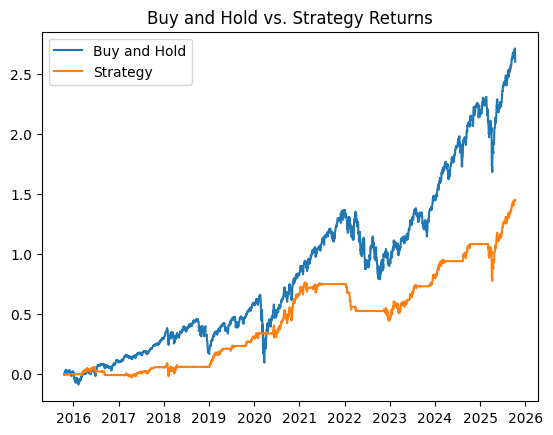

In [14]:
df['Strategy'] = np.where((df['VIX'] > df['Cutoff']) \
                        & (df['Weaker'] == True), 1, 0)

# shift the strategy back a day because we can only know the close after it closes
df['Strategy'] = df['Strategy'].shift(1)

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change(fill_method=None)).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change(fill_method=None) * \
                              df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])

    plt.title('Buy and Hold vs. Strategy Returns')
    plt.legend(['Buy and Hold', 'Strategy'])

    return df.dropna()

test_strategy(df)